# Capstone — same physics, different information (CRN + knowledge ladder)

This notebook ties the blog arc together: **one weather draw** (shared exogenous physics) replayed
under **different observation glasses** (P0→F2). SIM-02 **common random numbers (CRN)** lock demand,
spoilage, and arrival draws to `PHYSICS_RUN_ID` while each knowledge rung applies its own
`mask_for(scenario)` filter path. The headline question from notebook 09 — *what is knowing more
worth in profit?* — only makes sense when scenarios see the **same** shelf reality.

Library entry points:

- `voi/crn.py` — `run_voi_crn_cell` (Rust kernel; shared physics across all seven arms)
- `simulator/session.py` — `EngineSession` (browser / Pyodide / WASM studio path)
- `sim/m2_multi_scenario.py` — legacy Python closed-loop report (P1 arm removed post-T-121)

**Studio mirror:** observation chips in `web/src/controls.ts` call `set_obs_scenario` (T-113) —
the same ladder ids as `VOI_SCENARIOS` minus oracle `B-state` (verification ceiling, not a chip).

## Setup

Interactive cells below use the **Rust compute kernel** (ADR 0127 / T-121 Wave F).

```bash
uv sync --extra notebooks --extra viz --extra rust --python 3.11
cd crates/voi_py && uv run maturin develop --release
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

Without `_core`, `run_voi_crn_cell` and `EngineSession` raise — there is no Python episode loop fallback.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from types import SimpleNamespace

# Rust kernel is required (default per ADR 0127 when built).
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.filter.types import mask_for
from blueberries_voi.rng import STREAM_DEMAND, spawn_rng
from blueberries_voi.sim.profit import DEFAULT_PROFIT_COSTS, day_profit
from blueberries_voi.sim.shipments import smoke_cool_shipments
from blueberries_voi.simulator import DEMO_BUDGETS, EngineSession
from blueberries_voi.voi import PHYSICS_RUN_ID, VOI_SCENARIOS, run_voi_crn_cell

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").exists():
    REPO_ROOT = REPO_ROOT.parent
FIG_CAP = REPO_ROOT / "figures" / "capstone"
FIG_CAP.mkdir(parents=True, exist_ok=True)

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "blueberries_voi._core is not importable. Build with:\n"
        "  cd crates/voi_py && uv run maturin develop --release"
    )

ROOT_SEED = 42
N_WEEK = 7

print(f"Backend: {os.environ['BLUEBERRIES_VOI_BACKEND']!r}  rust_available={rust_available()}")
print(f"PHYSICS_RUN_ID = {PHYSICS_RUN_ID!r}")
print(f"VOI scenarios: {VOI_SCENARIOS}")

Backend: 'rust'  rust_available=True
PHYSICS_RUN_ID = 'voi-physics'
VOI scenarios: ('P0', 'P1', 'F1', 'F1s', 'F2a', 'F2', 'B-state')


## SIM-02: shared physics via `voi/crn.py`

`PHYSICS_RUN_ID = "voi-physics"` is the **single** `run_id` for exogenous streams inside a VOI cell.
Demand RNG addressing stays `(root_seed, PHYSICS_RUN_ID, day, :demand)` — never keyed by scenario
label (T-084 / ADR 0113).

Filter resampling and belief updates use **per-scenario** tags so P0 and F2 can diverge in
*information* without re-drawing weather. Python `rng.spawn_rng` and the Rust `voi_core` kernel
share the same semantic slots (structural parity, not necessarily bit-identical cross-language).

In [2]:
# Demand draws for days 0..2 are stable and independent of scenario label.
for day in range(3):
    g = spawn_rng(ROOT_SEED, run_id=PHYSICS_RUN_ID, day=day, stream=STREAM_DEMAND)
    print(f"day {day}: demand draw sample = {g.integers(0, 100)}")

# Scenario masks are distinct observation glasses on the same RichObs schema.
assert mask_for("P0").present ^ mask_for("P1").present == {"waste_total"}
assert "pack_date" in mask_for("F2a").present

day 0: demand draw sample = 9
day 1: demand draw sample = 54
day 2: demand draw sample = 38


## Studio observation chips ↔ knowledge ladder

The browser studio (`web/src/controls.ts`, ADR 0110 / T-089) exposes six **clickable chips**
(`OBS_LADDER_IDS`). Each maps to `config.obs_scenario` and live `set_obs_scenario` catch-up (T-113).

| Chip id | Studio title | New signal vs previous rung |
| --- | --- | --- |
| `P0` | Books only | receipts + POS totals |
| `P1` | Shrink gun | + daily waste totals |
| `F1` | Lot ID at POS | + lot-resolved sales |
| `F1s` | Lot ID on shrink | + lot-resolved waste |
| `F2a` | Pack date on ASN | + pack date prior |
| `F2` | Age at receipt | + measured τ at receipt |

`B-state` is the oracle verification arm in `VOI_SCENARIOS` — **not** a studio chip (no fabricated
observations). See notebook 05 for mask tables and retail mapping.

In [3]:
# Locked copy mirrors web/src/controls.ts SCENARIO_COPY (keep in sync manually).
SCENARIO_COPY = {
    "P0": ("Books only", "Receipts and POS totals only — no daily waste."),
    "P1": ("Shrink gun", "Adds storewide daily waste totals."),
    "F1": ("Lot ID at POS", "Sales broken out by lot."),
    "F1s": ("Lot ID on shrink", "Waste broken out by lot."),
    "F2a": ("Pack date on ASN", "Narrows the arrival-age prior only."),
    "F2": ("Age at receipt", "Measured age at receipt plus rich lot maps."),
}

chip_rows = [
    {"id": sid, "title": SCENARIO_COPY[sid][0], "description": SCENARIO_COPY[sid][1]}
    for sid in SCENARIO_COPY
]
chip_rows

[{'id': 'P0',
  'title': 'Books only',
  'description': 'Receipts and POS totals only — no daily waste.'},
 {'id': 'P1',
  'title': 'Shrink gun',
  'description': 'Adds storewide daily waste totals.'},
 {'id': 'F1',
  'title': 'Lot ID at POS',
  'description': 'Sales broken out by lot.'},
 {'id': 'F1s',
  'title': 'Lot ID on shrink',
  'description': 'Waste broken out by lot.'},
 {'id': 'F2a',
  'title': 'Pack date on ASN',
  'description': 'Narrows the arrival-age prior only.'},
 {'id': 'F2',
  'title': 'Age at receipt',
  'description': 'Measured age at receipt plus rich lot maps.'}]

## One `root_seed` CRN cell — scored profit by rung

`run_voi_crn_cell` runs burn-in + scored days for **every** scenario under the same physics seed.
We use a **smoke budget** (1 burn + 7 score days) for notebook interactivity — not citeable headline
VOI (see notebook 09 production presets).

This is the batch path behind `run_voi_sweep`; `sim/m2_multi_scenario.py` was the pre-T-121 Python
report writer (primary P1/B-state/Rung0) and now raises for P1 closed-loop — prefer this cell or
`EngineSession` for live demos.

In [4]:
crn_profits = run_voi_crn_cell(
    beta=2.0,
    root_seed=ROOT_SEED,
    scenarios=list(VOI_SCENARIOS),
    n_burn=1,
    n_score=N_WEEK,
    filter_n=16,
    H=2,
    n_rollout_paths=1,
    lead_time=1,
    shipments=smoke_cool_shipments(),
)

assert set(crn_profits) == set(VOI_SCENARIOS)
assert all(np.isfinite(v) for v in crn_profits.values())

p0_profit = float(crn_profits["P0"])
voi_deltas = {s: float(crn_profits[s]) - p0_profit for s in VOI_SCENARIOS}

print(f"{'scenario':10s} {'profit':>10s} {'Δ$ vs P0':>12s}")
print("-" * 36)
for s in VOI_SCENARIOS:
    print(f"{s:10s} {crn_profits[s]:10.2f} {voi_deltas[s]:11.2f}")

scenario       profit     Δ$ vs P0
------------------------------------
P0              89.50        0.00
P1              56.00      -33.50
F1              56.00      -33.50
F1s             56.00      -33.50
F2a             56.00      -33.50
F2              49.50      -40.00
B-state         56.00      -33.50


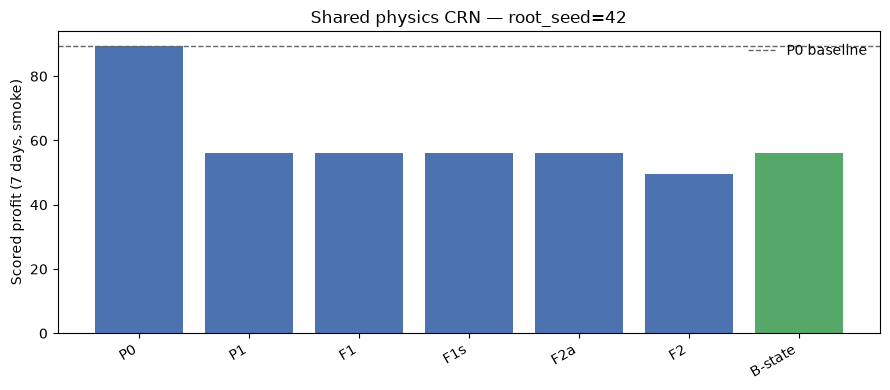

Wrote /home/oliver/blog/blueberries-voi/figures/capstone/crn_profit_by_rung_smoke.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(VOI_SCENARIOS))
profits = [crn_profits[s] for s in VOI_SCENARIOS]
colors = ["#4c72b0" if s != "B-state" else "#55a868" for s in VOI_SCENARIOS]
ax.bar(xs, profits, color=colors)
ax.axhline(p0_profit, color="0.4", ls="--", lw=1, label="P0 baseline")
ax.set_xticks(xs, VOI_SCENARIOS, rotation=30, ha="right")
ax.set_ylabel(f"Scored profit ({N_WEEK} days, smoke)")
ax.set_title(f"Shared physics CRN — root_seed={ROOT_SEED}")
ax.legend(frameon=False)
fig.tight_layout()
out_bar = FIG_CAP / "crn_profit_by_rung_smoke.png"
fig.savefig(out_bar, dpi=150)
plt.show()
print("Wrote", out_bar)

## `EngineSession` week replay — physics, belief, orders, cumulative P&L

The studio stepping surface (`EngineSession.init` → `act`) is what Pyodide/WASM workers call. One
week with **`act()`** (damped SW + rollout policy inside Rust) records per-day:

1. **Physics** — `day.demand`, arrivals, sales, waste
2. **Belief** — flat `lot_counts` + `age_marginals` (arrival-prior semantics, ADR 0106)
3. **Orders** — `day.order_qty` (MWF schedule inside kernel)
4. **Cumulative profit** — SIM-01=B `day_profit` summed with `DEFAULT_PROFIT_COSTS`

> **`BLUEBERRIES_VOI_BACKEND=rust`**: both this session and `run_voi_crn_cell` dispatch to
> `blueberries_voi._core.PyEngineSession` / `run_voi_crn_cell_py`. Set the env var explicitly in
> notebooks if your shell default differs.

In [6]:
def _session_config(*, obs_scenario: str = "P1") -> dict:
    return {
        "shipments": smoke_cool_shipments(),
        "n_particles": int(DEMO_BUDGETS["n_particles"]),
        "H": int(DEMO_BUDGETS["H"]),
        "n_rollout_paths": int(DEMO_BUDGETS["n_rollout_paths"]),
        "candidate_case_radius": int(DEMO_BUDGETS["candidate_case_radius"]),
        "L": 2,
        "K": 4,
        "enable_filter": True,
        "lead_time": 1,
        "obs_scenario": obs_scenario,
    }


def age_posterior_spread(belief: dict) -> float:
    """Std dev of age marginal on lot 0 (diagnostic scalar)."""
    grid = np.asarray(belief["tau_grid"], dtype=float)
    am = np.asarray(belief["age_marginals"], dtype=float).reshape(
        int(belief["L"]), int(belief["K"])
    )
    w = am[0] / max(float(am[0].sum()), 1e-12)
    mean = float((grid * w).sum())
    return float(np.sqrt(((grid - mean) ** 2 * w).sum()))


def replay_week(*, root_seed: int, obs_scenario: str = "P1", n_days: int = N_WEEK) -> dict:
    session = EngineSession()
    session.init(_session_config(obs_scenario=obs_scenario), seed=root_seed)
    days: list[dict] = []
    cum_profit = 0.0
    for _ in range(n_days):
        delta = session.act()
        day = delta["day"]
        dp = day_profit(
            SimpleNamespace(
                demand=int(day["demand"]),
                sales_total=int(day["sales_total"]),
                waste_total=int(day["waste_total"]),
            ),
            DEFAULT_PROFIT_COSTS,
        )
        cum_profit += dp
        days.append(
            {
                "episode_day": int(delta["episode_day"]),
                "demand": int(day["demand"]),
                "order_qty": int(day["order_qty"]),
                "sales_total": int(day["sales_total"]),
                "waste_total": int(day["waste_total"]),
                "day_profit": float(dp),
                "cum_profit": float(cum_profit),
                "age_spread": age_posterior_spread(delta["belief"]),
                "on_hand": float(sum(delta["belief"]["lot_counts"])),
            }
        )
    return {"obs_scenario": obs_scenario, "days": days}


week_p1 = replay_week(root_seed=ROOT_SEED, obs_scenario="P1")
assert len(week_p1["days"]) == N_WEEK
week_p1["days"][:3]

[{'episode_day': 0,
  'demand': 16,
  'order_qty': 0,
  'sales_total': 0,
  'waste_total': 0,
  'day_profit': -48.0,
  'cum_profit': -48.0,
  'age_spread': 2.148672982935734,
  'on_hand': 5.343462116328819},
 {'episode_day': 1,
  'demand': 32,
  'order_qty': 88,
  'sales_total': 0,
  'waste_total': 0,
  'day_profit': -96.0,
  'cum_profit': -144.0,
  'age_spread': 2.1450032002919825,
  'on_hand': 3.9791313386089837},
 {'episode_day': 2,
  'demand': 17,
  'order_qty': 0,
  'sales_total': 0,
  'waste_total': 0,
  'day_profit': -51.0,
  'cum_profit': -195.0,
  'age_spread': 1.3161560191203272,
  'on_hand': 89.6449999999997}]

### Multi-panel week timeline

Four stacked panels for the P1 replay: exogenous demand (physics), controller orders, belief age
spread, and cumulative scaffold profit.

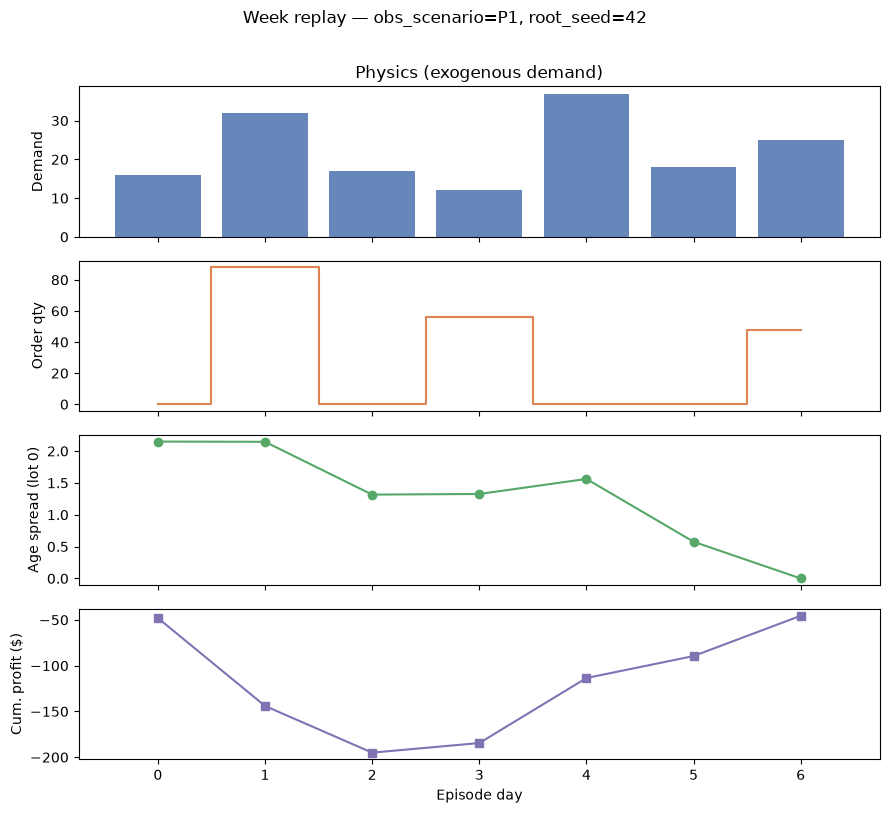

Wrote /home/oliver/blog/blueberries-voi/figures/capstone/week_timeline_p1_seed42.png


In [7]:
def plot_week_timeline(replay: dict, *, title_suffix: str = "") -> Path:
    days = replay["days"]
    t = [d["episode_day"] for d in days]
    fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

    axes[0].bar(t, [d["demand"] for d in days], color="#4c72b0", alpha=0.85)
    axes[0].set_ylabel("Demand")
    axes[0].set_title("Physics (exogenous demand)")

    axes[1].step(t, [d["order_qty"] for d in days], where="mid", color="#dd8452")
    axes[1].set_ylabel("Order qty")

    axes[2].plot(t, [d["age_spread"] for d in days], marker="o", color="#55a868")
    axes[2].set_ylabel("Age spread (lot 0)")

    axes[3].plot(t, [d["cum_profit"] for d in days], marker="s", color="#8172b3")
    axes[3].set_ylabel("Cum. profit ($)")
    axes[3].set_xlabel("Episode day")

    tag = replay["obs_scenario"]
    fig.suptitle(
        f"Week replay — obs_scenario={tag}, root_seed={ROOT_SEED}{title_suffix}",
        y=1.01,
    )
    fig.tight_layout()
    out = FIG_CAP / f"week_timeline_{tag.lower()}_seed{ROOT_SEED}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    return out


timeline_path = plot_week_timeline(week_p1)
print("Wrote", timeline_path)

## Studio chip switch: `set_obs_scenario` catch-up (T-113)

Clicking a different observation chip mid-episode does **not** re-roll physics. The Rust session
replays the richest log into a new filter bank for the target mask — same demand path, different
belief/export. Demo: run three days as P0, catch up to F2, continue stepping.

In [8]:
session = EngineSession()
session.init(_session_config(obs_scenario="P0"), seed=ROOT_SEED)
pre = [session.act() for _ in range(3)]
demands_before = [d["day"]["demand"] for d in pre]

snap = session.set_obs_scenario("F2")
assert snap["applied_config"]["obs_scenario"] == "F2"
post = session.act()
demands_after = demands_before + [post["day"]["demand"]]

print("Demands days 0-3:", demands_after)
print("Belief age spread after F2 catch-up:", age_posterior_spread(post["belief"]))

Demands days 0-3: [16, 32, 17, 12]
Belief age spread after F2 catch-up: 0.9112628599915613


## Takeaways

1. **Fair VOI comparisons require CRN** — `PHYSICS_RUN_ID` shares weather; scenario tags own filter noise.
2. **Knowledge ladder ≠ physics ladder** — P0→F2 changes glasses, not the demand/spoil/arrival draws inside a CRN cell.
3. **Two entry points, one kernel** — batch `run_voi_crn_cell` for sweep headlines; `EngineSession` for studio stepping and chip catch-up.
4. **Chips are scenario ids** — `web/src/controls.ts` titles match `mask_for` rungs; oracle `B-state` stays off-ui.
5. **Rust is mandatory** — export `BLUEBERRIES_VOI_BACKEND=rust` when building `_core`; notebook cells will raise otherwise.

Further reading: notebook 05 (masks), notebook 09 (VOI sweep), ADR [`0127`](../.team/adr/0127-rust-compute-kernel.md), spec T-113 / ADR 0123 (obs scenario caches).